In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import os
import kagglehub

path = kagglehub.dataset_download("vinicius150987/titanic3")
csv_path = os.path.join(path, "titanic3.xls")
os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_excel(csv_path)

In [3]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
df.shape

(1309, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), object(2), str(5)
memory usage: 143.3+ KB


In [6]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [7]:
df["survived"].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [8]:
null_analysis_df = df.isna().sum().to_frame(name="Number of Missing values")

In [9]:
null_analysis_df["Missing percent"] = df.isna().mean() * 100

In [10]:
null_analysis_df

,Number of Missing values,Missing percent
pclass,0,0.000000
survived,0,0.000000
name,0,0.000000
sex,0,0.000000
age,263,20.091673
sibsp,0,0.000000
parch,0,0.000000
ticket,0,0.000000
fare,1,0.076394
cabin,1014,77.463713


In [11]:
sns.set_style("whitegrid")

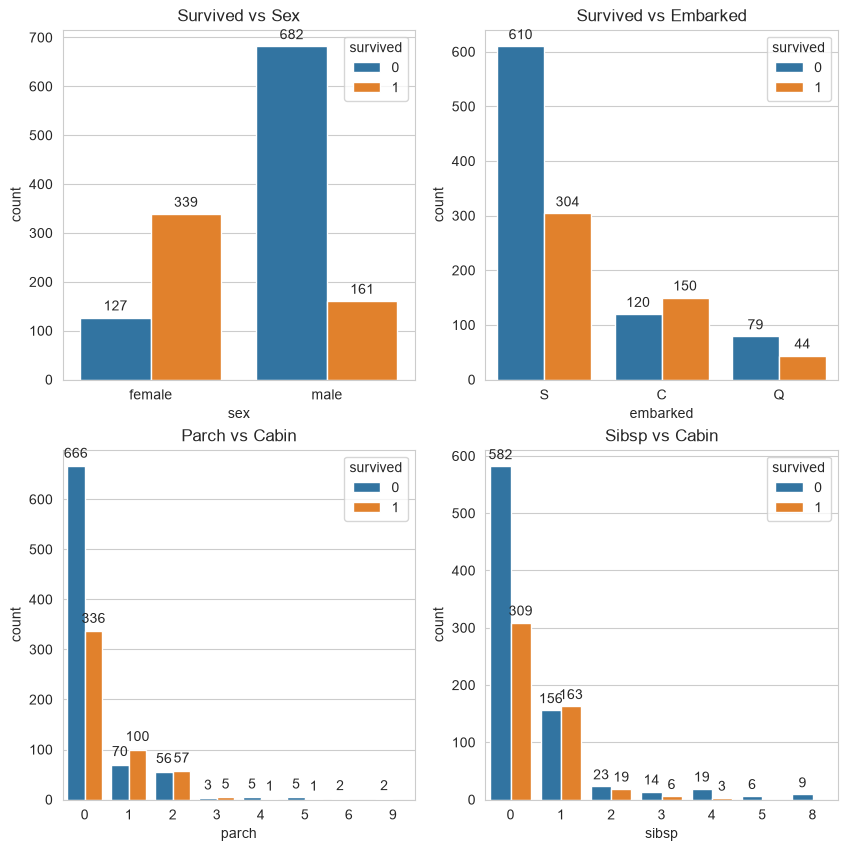

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
s_s = sns.countplot(x=df["sex"], hue=df["survived"], ax=axes[0, 0])
for container in s_s.containers:
    s_s.bar_label(container, padding=3)
axes[0, 0].set_title("Survived vs Sex")

embarked_s = sns.countplot(x=df["embarked"], hue=df["survived"], ax=axes[0, 1])
for container in embarked_s.containers:
    embarked_s.bar_label(container, padding=3)
axes[0, 1].set_title("Survived vs Embarked")


parch_s = sns.countplot(x=df["parch"], hue=df["survived"], ax=axes[1,0])
for container in parch_s.containers:
    parch_s.bar_label(container=container, padding=4)
axes[1, 0].set_title("Parch vs Cabin")

sibsp_s = sns.countplot(x=df["sibsp"], hue=df["survived"], ax=axes[1,1])
for container in sibsp_s.containers:
    sibsp_s.bar_label(container=container, padding=3)
axes[1, 1].set_title("Sibsp vs Cabin")
plt.savefig("images/4_col_eda.png")
plt.show()

In [13]:
binned_data, bin_edges = pd.qcut(df["fare"], q=10, retbins=True)
bin_edges[0] = -float("inf")
bin_edges[-1] = float("inf")
df["fare_binned"] = pd.cut(df["fare"], bins=bin_edges)

In [14]:
historical_bins = [0, 1, 12, float('inf')]

# Corresponding legal/ticket labels from 1912
historical_labels = ['Infant', 'Child', 'Adult']

df["age_binned"] = pd.cut(df["age"], bins=historical_bins, labels=historical_labels)

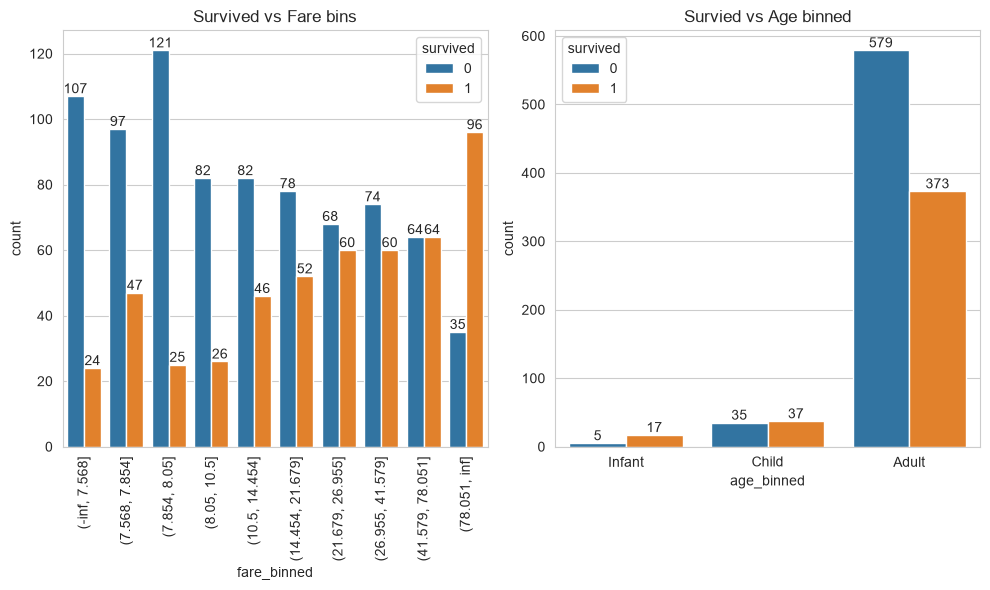

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(10, 6))

fbinned_s = sns.countplot(x=df["fare_binned"], hue=df["survived"], ax=axes[0])
for container in fbinned_s.containers:
    fbinned_s.bar_label(container)
axes[0].set_title("Survived vs Fare bins")
axes[0].tick_params(axis="x", rotation=90)

abinned_s = sns.countplot(x=df["age_binned"], hue=df["survived"], ax=axes[1])
for container in abinned_s.containers:
    abinned_s.bar_label(container)
axes[1].set_title("Survied vs Age binned")
plt.tight_layout()
plt.savefig("images/survival_vs_age_fare_binned.png")
plt.show()

In [16]:
df["name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())

0         Miss
1       Master
2         Miss
3           Mr
4          Mrs
         ...  
1304      Miss
1305      Miss
1306        Mr
1307        Mr
1308        Mr
Name: name, Length: 1309, dtype: str

In [17]:
df["titles"] = df["name"].str.split(",").str[1].str.split(".").str[0].str.strip()

In [18]:
df["titles"].unique()

array(['Miss', 'Master', 'Mr', 'Mrs', 'Col', 'Mme', 'Dr', 'Major', 'Capt',
       'Lady', 'Sir', 'Mlle', 'Dona', 'Jonkheer', 'the Countess', 'Don',
       'Rev', 'Ms'], dtype=object)

In [19]:
df["titles"].value_counts()

titles
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Capt              1
Lady              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Name: count, dtype: int64

In [20]:
df.loc[df["titles"] == "Mlle", "titles"] = "Miss"
df.loc[(df["titles"] == "Mme") | (df["titles"] == "Ms") | (df["titles"] == "Lady") | (df["titles"] == "Countess") | (df["titles"] == "Dona"), "titles"] = "Mrs"
df.loc[df["titles"] == "Mlle", "titles"] = "Miss"
df.loc[(df["titles"] == "Dr") | (df["titles"] == "Rev") | (df["titles"] == "Col") | (df["titles"] == "Major") | (df["titles"] == "Capt") | (df["titles"] == "Don") | (df["titles"] == "Jonkheer") | (df["titles"] == "the Countess") | (df["titles"] == "Sir"), "titles"] = "Rare"

In [21]:
df["titles"].value_counts()

titles
Mr        757
Miss      262
Mrs       202
Master     61
Rare       27
Name: count, dtype: int64

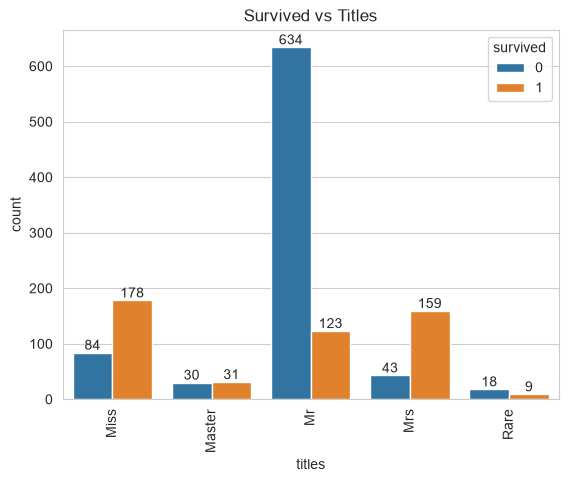

In [22]:
plt.title("Survived vs Titles")
titles_s = sns.countplot(x=df["titles"], hue=df["survived"])
for container in titles_s.containers:
    titles_s.bar_label(container)
plt.xticks(rotation=90)
plt.savefig("images/survived_vs_titles.png")
plt.show()

In [23]:
df["family"] = df["parch"] + df["sibsp"]

In [24]:
df["ticket_shared"] = df.groupby("ticket")["ticket"].transform("count")

In [25]:
pd.crosstab(df["ticket_shared"], df["family"])

family,0,1,2,3,4,5,6,7,10
ticket_shared,,,,,,,,,
1,673,35,16,1,0,0,2,0,0
2,60,170,25,6,1,0,0,0,0
3,17,24,101,0,1,1,0,0,0
4,17,4,11,28,0,0,0,0,0
5,6,2,3,4,15,0,0,0,0
6,2,0,0,4,0,18,0,0,0
7,7,0,3,0,5,6,14,0,0
8,8,0,0,0,0,0,0,8,0
11,0,0,0,0,0,0,0,0,11


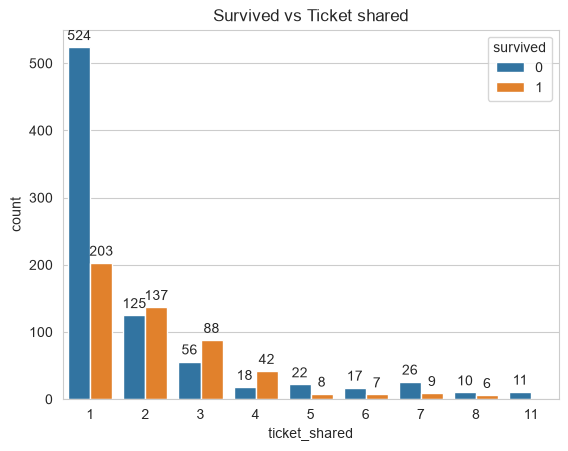

In [26]:
plt.title("Survived vs Ticket shared")
ticket_s = sns.countplot(x=df["ticket_shared"], hue=df["survived"])
for container in ticket_s.containers:
    ticket_s.bar_label(container, padding=3)
plt.savefig("images/survived_vs_ticket_shared.png")
plt.show()

In [27]:
df["has_cabin"] = df["cabin"].fillna(0)
df.loc[df["cabin"].notna(), "has_cabin"] = 1

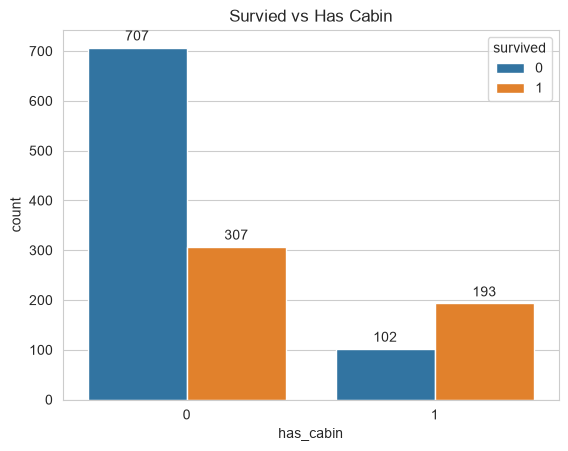

In [28]:
plt.title("Survied vs Has Cabin")
cabin_s = sns.countplot(x=df["has_cabin"], hue=df["survived"])
for container in cabin_s.containers:
    cabin_s.bar_label(container, padding=3)
plt.savefig("images/survived_vs_has_cabin.png")
plt.show()

In [29]:
df[df.duplicated()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,fare_binned,age_binned,titles,family,ticket_shared,has_cabin


In [30]:
pivot = df.groupby(["pclass", "sex"])["survived"].sum().unstack()

In [31]:
pivot = pivot.rename(columns={"female": "females_survived", "male": "males_survived"})

In [32]:
pivot

sex,females_survived,males_survived
pclass,,
1,139,61
2,94,25
3,106,75


In [33]:
pclass_sex_grouped = df.groupby(["pclass", "sex"])["sex"].count().unstack()
pclass_sex_grouped = pclass_sex_grouped.rename(columns={"female": "total_females", "male": "total_males"})

In [34]:
pclass_sex_grouped

sex,total_females,total_males
pclass,,
1,144,179
2,106,171
3,216,493


In [35]:
final_pivot = pd.concat([pivot, pclass_sex_grouped], axis=1)

In [36]:
final_pivot["percent_females_survived"] = (final_pivot["females_survived"] / final_pivot["total_females"]) * 100
final_pivot["percent_males_survived"] = (final_pivot["males_survived"] / final_pivot["total_males"]) * 100
final_pivot

sex,females_survived,males_survived,total_females,total_males,percent_females_survived,percent_males_survived
pclass,,,,,,
1,139,61,144,179,96.527778,34.078212
2,94,25,106,171,88.679245,14.619883
3,106,75,216,493,49.074074,15.212982


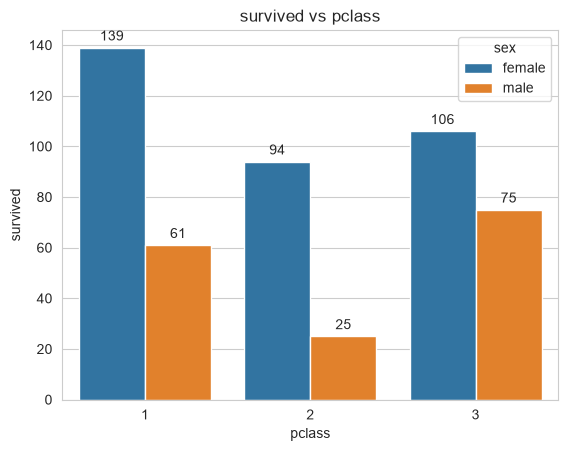

In [37]:
survivors_df = df.groupby(['pclass', 'sex'])['survived'].sum().reset_index()
plt.title("survived vs pclass")
pclass_sex_survived = sns.barplot(x="pclass", y="survived", hue="sex", data=survivors_df, estimator="sum")
for container in pclass_sex_survived.containers:
    pclass_sex_survived.bar_label(container, padding=3)
plt.savefig("images/survived_vs_pclass.png")
plt.show()

In [38]:
df = df.drop(columns=["name", "sibsp", "parch", "body", "home.dest", "cabin", "boat", "age_binned", "fare_binned", "ticket"])

In [39]:
df.head(1)

,pclass,survived,sex,age,fare,embarked,titles,family,ticket_shared,has_cabin
0,1,1,female,29.0,211.3375,S,Miss,0,1,1


In [40]:
df.columns

Index(['pclass', 'survived', 'sex', 'age', 'fare', 'embarked', 'titles',
       'family', 'ticket_shared', 'has_cabin'],
      dtype='str')

In [41]:
df["embarked"] = df["embarked"].fillna("Unknown")
cols = ["sex", "embarked", "titles"]
ord = OrdinalEncoder()
df[cols] = ord.fit_transform(df[cols]).astype(int)

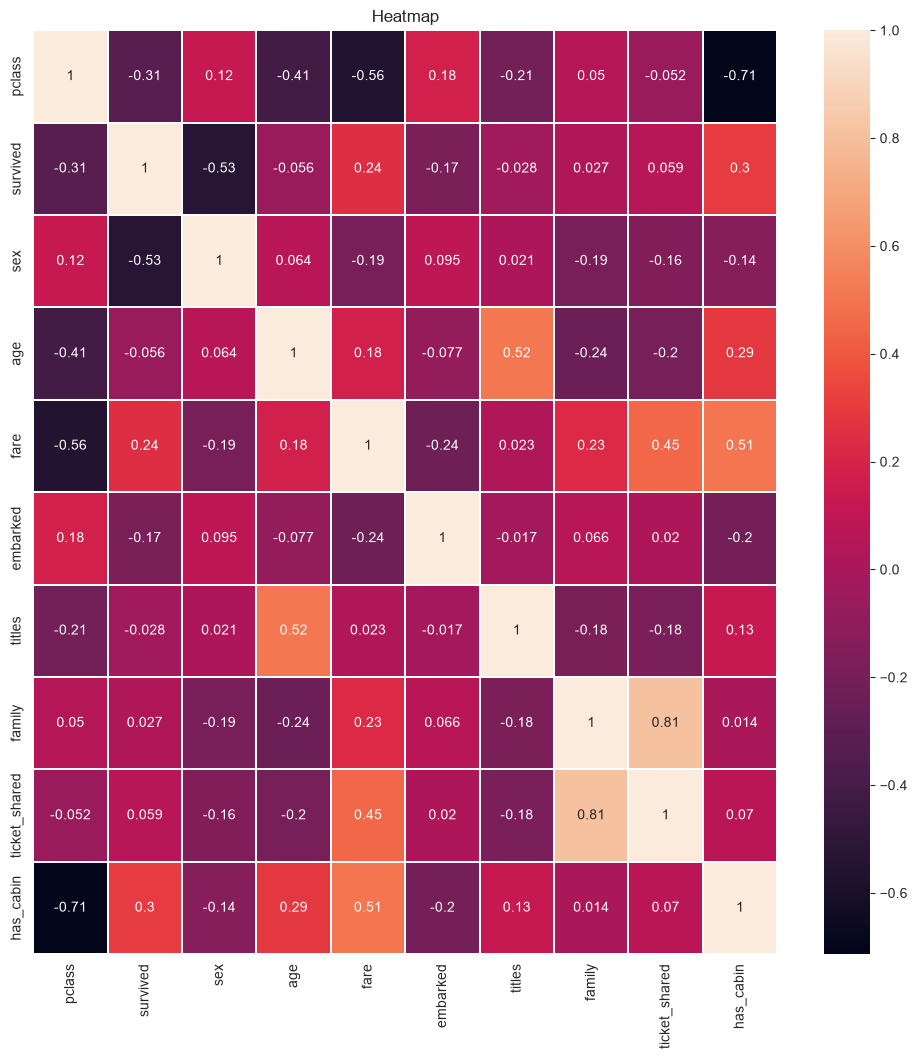

In [42]:
plt.figure(figsize=(12,12))
plt.title("Heatmap")
sns.heatmap(df.corr(), annot=True, linewidths=0.2)
plt.savefig("images/heatmap.png")
plt.show()

In [43]:
df.corr()

,pclass,survived,sex,age,fare,embarked,titles,family,ticket_shared,has_cabin
pclass,1.000000,-0.312469,0.124617,-0.408106,-0.558629,0.182154,-0.207535,0.050027,-0.052272,-0.713857
survived,-0.312469,1.000000,-0.528693,-0.055513,0.244265,-0.172526,-0.028313,0.026876,0.059056,0.302250
sex,0.124617,-0.528693,1.000000,0.063646,-0.185523,0.095215,0.021245,-0.188583,-0.157660,-0.137396
age,-0.408106,-0.055513,0.063646,1.000000,0.178739,-0.076678,0.515840,-0.240230,-0.196918,0.289740
fare,-0.558629,0.244265,-0.185523,0.178739,1.000000,-0.235763,0.023291,0.226492,0.452526,0.507253
embarked,0.182154,-0.172526,0.095215,-0.076678,-0.235763,1.000000,-0.017493,0.066396,0.020085,-0.201785
titles,-0.207535,-0.028313,0.021245,0.515840,0.023291,-0.017493,1.000000,-0.176080,-0.181756,0.125663
family,0.050027,0.026876,-0.188583,-0.240230,0.226492,0.066396,-0.176080,1.000000,0.808393,0.014155
ticket_shared,-0.052272,0.059056,-0.157660,-0.196918,0.452526,0.020085,-0.181756,0.808393,1.000000,0.070291
has_cabin,-0.713857,0.302250,-0.137396,0.289740,0.507253,-0.201785,0.125663,0.014155,0.070291,1.000000


In [44]:
df.head(1)

,pclass,survived,sex,age,fare,embarked,titles,family,ticket_shared,has_cabin
0,1,1,0,29.0,211.3375,2,1,0,1,1


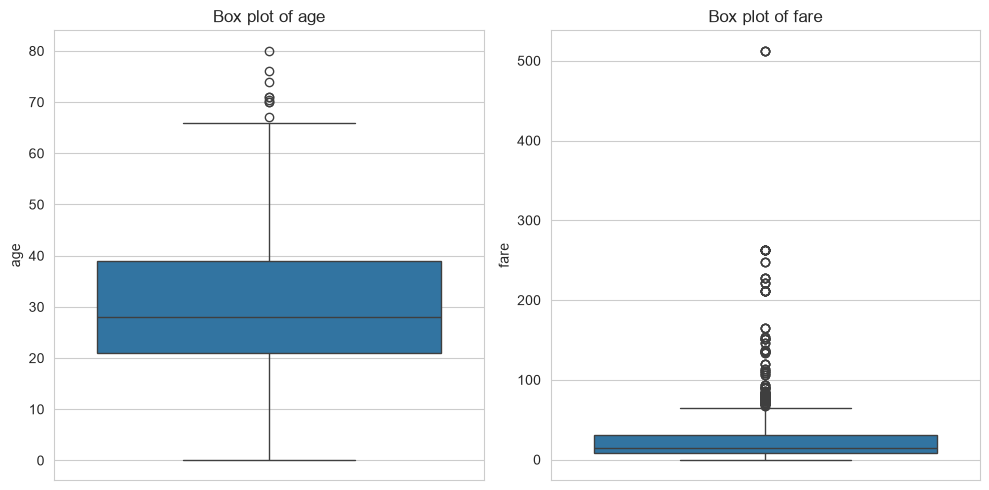

In [45]:
cols = ["age", "fare"]
fig, axes = plt.subplots(1, 2, figsize=(10,5))
for i, col in enumerate(cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(f"Box plot of {col}")
plt.tight_layout()
plt.savefig("images/box_plot_age.png")
plt.show()

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns and drop nulls
numerical_df = df.select_dtypes(include=["number"]).dropna()

vif_df = pd.DataFrame({
    "feature": numerical_df.columns,
    "VIF": [variance_inflation_factor(numerical_df.values, i)
            for i in range(numerical_df.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_df)

         feature       VIF
8  ticket_shared  8.733294
6         titles  8.408988
3            age  7.520178
0         pclass  7.212204
5       embarked  4.943865
7         family  3.825514
2            sex  3.418157
4           fare  2.886588
1       survived  2.029241


# EDA Inferences: Titanic Dataset

### Dataset Overview
* **Total passengers:** 1309
* **Survival rate:** ~38% survived, ~62% did not survive
* **Class imbalance:** Present (handled later with SMOTE)

### Missing Values
* **Age:** 263 missing (20%) — imputed with median in pipeline
* **Fare:** 1 missing — imputed with median in pipeline
* **Embarked:** 2 missing — imputed with most frequent in pipeline
* **Cabin:** 1014 missing (77%) — dropped due to excessive missingness
* **Boat, Body, Home.dest:** Dropped, not relevant to prediction

### Feature Insights
* **Sex:** Strongest predictor — female survival rate ~74%, male ~19%. Classic "women and children first" evacuation policy confirmed.
* **Pclass:** Clear survival hierarchy — 1st class ~63%, 2nd ~47%, 3rd ~24%. Higher class equaled better deck access and closer proximity to lifeboats.
* **Age:** Children (under 12) had higher survival rates, while elderly passengers had lower survival rates. Wide age range with outliers — log transformation not needed, median imputation used.
* **Fare:** Highly skewed with extreme outliers — log1p transformation applied. Higher fare strongly correlated with higher pclass and survival.
* **Family size:** Solo travelers and very large families survived less. Small families (1 to 4 members) had better survival rates. Engineered into family_binned: alone / small / large.
* **Embarked:** Minor predictor — Cherbourg (C) passengers survived slightly more. Likely because more 1st class passengers boarded at Cherbourg.

### Feature Engineering
* Extracted titles from name column (Mr, Mrs, Miss, Master, Rare). Titles encode both gender and social status. Rare titles grouped to avoid sparse categories.
* Created family = sibsp + parch (combines family size into one feature). VIF confirmed sibsp and parch were multicollinear — combining reduced VIF.
* family_binned created from family (alone/small/large).
* ticket_shared (people sharing ticket) tested — no improvement, dropped.
* age_bin added alongside raw age — no significant improvement observed.

### Multicollinearity (VIF Analysis)
* ticket_shared showed highest VIF (8.7) — dropped.
* titles VIF (8.4) — kept as it's highly predictive despite correlation.
* age and pclass showed moderate VIF — expected and acceptable.
* family VIF acceptable after combining sibsp and parch.

### Preprocessing Decisions
* **Fare:** log1p transformation to handle skew + StandardScaler
* **Age:** median imputation + age binning + StandardScaler  
* **Categorical:** OneHotEncoding for embarked, titles, family_binned
* **Sex:** OrdinalEncoding (binary — male/female)
* **Pclass, family:** most_frequent imputation, no scaling needed